# UNSW-NB15 — CNN Multiclass Intrusion Detection
**Pipeline:** Preprocessing -> PyTorch DataLoaders -> CNN -> 5-Fold CV -> Evaluation

**Task:** Multiclass classification — 10 attack categories (Normal, Fuzzers, DoS, Exploits, ...)

## 1. Configuration

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
DATA_PATH        = '/content/drive/MyDrive/Tez_kodu/UNSW-NB15'
MISSING_STRATEGY = 'mean'
SCALING          = 'quantile'
SPLIT            = 'stratified'
OVERSAMPLING     = 'smote'
TASK             = 'multiclass'
ENCODING         = 'onehot'
LOSS_CHOICE      = 'focal'
TEST_SIZE        = 0.2
RANDOM_STATE     = 42

#  CNN Hyperparameters
BATCH_SIZE   = 256
EPOCHS       = 50
LR           = 1e-3
N_FOLDS      = 5
PATIENCE     = 7

# CNN blocks: list of (out_channels, kernel_size)
CNN_BLOCKS   = [(64, 3), (128, 3), (256, 3)]
CNN_DROPOUT  = 0.3
POOL_SIZE    = 2   # set to 1 to disable MaxPool

# Classifier head
FC_LAYERS    = [256, 128]   # hidden FC dims after GlobalAvgPool
FC_DROPOUT   = 0.4

print(' Configuration loaded')
print(f'  Task: {TASK} | Scaling: {SCALING} | Oversampling: {OVERSAMPLING}')
print(f'  Loss: {LOSS_CHOICE} | CNN blocks: {CNN_BLOCKS}')
print(f'  Batch: {BATCH_SIZE} | Epochs: {EPOCHS} | Folds: {N_FOLDS} | Patience: {PATIENCE}')

 Configuration loaded
  Task: multiclass | Scaling: quantile | Oversampling: smote
  Loss: focal | CNN blocks: [(64, 3), (128, 3), (256, 3)]
  Batch: 256 | Epochs: 50 | Folds: 5 | Patience: 7


## 2. Imports

In [4]:
import os, glob, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, QuantileTransformer,
    LabelEncoder, OneHotEncoder, TargetEncoder, label_binarize
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score,
    precision_recall_curve, roc_curve, auc
)

from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN, RandomOverSampler
from imblearn.combine import SMOTETomek

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Imports OK  |  Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

 Imports OK  |  Device: cuda
  GPU: NVIDIA L4


## 3. Data Loading

In [5]:
if os.path.isdir(DATA_PATH):
    csv_files = glob.glob(os.path.join(DATA_PATH, '*.csv'))
    print(f'{len(csv_files)} CSV files found:')
    for f in csv_files:
        print(f'   {os.path.basename(f)}')
    df = pd.concat([pd.read_csv(f, low_memory=False) for f in csv_files], ignore_index=True)
else:
    df = pd.read_csv(DATA_PATH, low_memory=False)

df.columns = df.columns.str.strip().str.lower()
print(f'\nShape: {df.shape}')
print(f'Columns sample: {list(df.columns[:8])}')

2 CSV files found:
   UNSW_NB15_training-set.csv
   UNSW_NB15_testing-set.csv

Shape: (257673, 45)
Columns sample: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes']


## 4. Cleaning & Encoding

In [6]:
# 4.1 Infinite -> NaN
inf_count = np.isinf(df.select_dtypes(include=np.number)).sum().sum()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'{inf_count:,} infinite values replaced by NaN')

# 4.2 Missing values
if MISSING_STRATEGY == 'drop':
    df.dropna(inplace=True)
else:
    num_cols = df.select_dtypes(include=np.number).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
print(f'Missing after: {df.isnull().sum().sum()}')

# 4.3 Multiclass target: attack_cat → LabelEncoder
df['attack_cat'] = (df['attack_cat']
                    .astype(str).str.strip()
                    .replace({'nan': 'Normal', '': 'Normal'}))
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['attack_cat'])
CLASS_NAMES = list(le.classes_)
N_CLASSES   = len(CLASS_NAMES)
print(f'\nLabel mapping ({N_CLASSES} classes):')
for i, cls in enumerate(CLASS_NAMES):
    cnt = (df['label_encoded'] == i).sum()
    print(f'  {i:2d} : {cls:<20} {cnt:>8,}')

# 4.4 Categorical OneHot
EXCLUDE  = ['label', 'attack_cat', 'label_encoded']
cat_cols = [c for c in df.select_dtypes(include='object').columns if c not in EXCLUDE]
if cat_cols and ENCODING == 'onehot':
    df = pd.get_dummies(df, columns=cat_cols, drop_first=False)
    print(f'OneHot applied on: {cat_cols}')

# 4.5 Feature matrix
FEATURE_COLS = [c for c in df.select_dtypes(include=np.number).columns if c not in EXCLUDE]
X = df[FEATURE_COLS].copy().astype(np.float32)
y = df['label_encoded'].values.astype(np.int64)

N_FEATURES = X.shape[1]
print(f'\nFeatures: {N_FEATURES} | Samples: {X.shape[0]:,} | Classes: {N_CLASSES}')

0 infinite values replaced by NaN
Missing after: 0

Label mapping (10 classes):
   0 : Analysis                2,677
   1 : Backdoor                2,329
   2 : DoS                    16,353
   3 : Exploits               44,525
   4 : Fuzzers                24,246
   5 : Generic                58,871
   6 : Normal                 93,000
   7 : Reconnaissance         13,987
   8 : Shellcode               1,511
   9 : Worms                     174
OneHot applied on: ['proto', 'service', 'state']

Features: 40 | Samples: 257,673 | Classes: 10


## 5. Train / Validation / Test Split

In [7]:
stratify_param = y if SPLIT == 'stratified' else None
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=stratify_param
)
stratify_temp = y_temp if SPLIT == 'stratified' else None
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.333, random_state=RANDOM_STATE, stratify=stratify_temp
)
print(f'Split ({SPLIT})')
print(f'  Train      : {X_train.shape[0]:,} (70%)')
print(f'  Validation : {X_val.shape[0]:,} (10%)')
print(f'  Test       : {X_test.shape[0]:,} (20%)')

Split (stratified)
  Train      : 180,371 (70%)
  Validation : 25,742 (10%)
  Test       : 51,560 (20%)


## 6. Scaling

In [8]:
if SCALING is None:
    X_train_scaled = X_train.values.astype(np.float32)
    X_val_scaled   = X_val.values.astype(np.float32)
    X_test_scaled  = X_test.values.astype(np.float32)
    print('No scaling applied')
else:
    scalers = {
        'standard': StandardScaler(),
        'minmax'  : MinMaxScaler(),
        'quantile': QuantileTransformer(output_distribution='normal', random_state=RANDOM_STATE)
    }
    scaler = scalers[SCALING]
    X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
    X_val_scaled   = scaler.transform(X_val).astype(np.float32)
    X_test_scaled  = scaler.transform(X_test).astype(np.float32)
    print(f' Scaling [{SCALING}] applied — fit on train only')

 Scaling [quantile] applied — fit on train only


## 7. Oversampling (train only)

In [9]:
y_train_arr = y_train if isinstance(y_train, np.ndarray) else np.array(y_train)
print(f'Before: {dict(zip(*np.unique(y_train_arr, return_counts=True)))}')

if OVERSAMPLING is None:
    X_train_res, y_train_res = X_train_scaled, y_train_arr
    print('No oversampling')
else:
    oversamplers = {
        'smote'           : SMOTE(random_state=RANDOM_STATE),
        'borderline_smote': BorderlineSMOTE(random_state=RANDOM_STATE),
        'adasyn'          : ADASYN(random_state=RANDOM_STATE),
        'smote_tomek'     : SMOTETomek(random_state=RANDOM_STATE),
        'random'          : RandomOverSampler(random_state=RANDOM_STATE)
    }
    sampler = oversamplers[OVERSAMPLING]
    X_train_res, y_train_res = sampler.fit_resample(X_train_scaled, y_train_arr)
    X_train_res = X_train_res.astype(np.float32)
    y_train_res = y_train_res.astype(np.int64)
    print(f' {OVERSAMPLING} applied')

print(f'After : {dict(zip(*np.unique(y_train_res, return_counts=True)))}')
print(f'Train size: {X_train_res.shape[0]:,}')

Before: {np.int64(0): np.int64(1874), np.int64(1): np.int64(1630), np.int64(2): np.int64(11447), np.int64(3): np.int64(31167), np.int64(4): np.int64(16972), np.int64(5): np.int64(41210), np.int64(6): np.int64(65100), np.int64(7): np.int64(9791), np.int64(8): np.int64(1058), np.int64(9): np.int64(122)}
 smote applied
After : {np.int64(0): np.int64(65100), np.int64(1): np.int64(65100), np.int64(2): np.int64(65100), np.int64(3): np.int64(65100), np.int64(4): np.int64(65100), np.int64(5): np.int64(65100), np.int64(6): np.int64(65100), np.int64(7): np.int64(65100), np.int64(8): np.int64(65100), np.int64(9): np.int64(65100)}
Train size: 651,000


## 8. PyTorch Dataset & DataLoaders

In [10]:
class IDSDataset(Dataset):
    """Input shape for CNN: (N, 1, F) — 1 channel, F features as 1-D sequence."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N,1,F)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):           return len(self.y)
    def __getitem__(self, idx):  return self.X[idx], self.y[idx]


def make_loader(X, y, batch_size, shuffle=True):
    return DataLoader(
        IDSDataset(X, y),
        batch_size  = batch_size,
        shuffle     = shuffle,
        drop_last   = True,
        num_workers = 0,
        pin_memory  = (DEVICE.type == 'cuda')
    )


train_loader = make_loader(X_train_res,   y_train_res, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val_scaled,  y_val,       BATCH_SIZE, shuffle=False)
test_loader  = make_loader(X_test_scaled, y_test,      BATCH_SIZE, shuffle=False)

print(f' DataLoaders created (drop_last=True)')
print(f'  Train batches: {len(train_loader)}')
print(f'  Val   batches: {len(val_loader)}')
print(f'  Test  batches: {len(test_loader)}')
xb, yb = next(iter(train_loader))
print(f'  Batch shape  : X={tuple(xb.shape)}  y={tuple(yb.shape)}')

 DataLoaders created (drop_last=True)
  Train batches: 2542
  Val   batches: 100
  Test  batches: 201
  Batch shape  : X=(256, 1, 40)  y=(256,)


## 9. CNN Architecture

In [11]:
class CNN1D(nn.Module):

    def __init__(self, n_features, n_classes,
                 blocks=None, cnn_dropout=0.3,
                 pool_size=2, fc_layers=None, fc_dropout=0.4):
        super().__init__()
        if blocks    is None: blocks    = [(64,3),(128,3),(256,3)]
        if fc_layers is None: fc_layers = [256, 128]

        # Convolutional blocks
        cnn_mods = []
        in_ch = 1
        for out_ch, k in blocks:
            cnn_mods += [
                nn.Conv1d(in_ch, out_ch, kernel_size=k,
                          padding=k // 2, bias=False),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(inplace=True),
                nn.Dropout(cnn_dropout),
            ]
            if pool_size > 1:
                cnn_mods.append(nn.MaxPool1d(pool_size))
            in_ch = out_ch
        self.cnn    = nn.Sequential(*cnn_mods)
        self.gap    = nn.AdaptiveAvgPool1d(1)   # GlobalAveragePooling
        cnn_out_dim = blocks[-1][0]

        # Fully-connected head
        fc_mods = []
        in_dim  = cnn_out_dim
        for out_dim in fc_layers:
            fc_mods += [
                nn.Linear(in_dim, out_dim, bias=False),
                nn.BatchNorm1d(out_dim),
                nn.ReLU(inplace=True),
                nn.Dropout(fc_dropout),
            ]
            in_dim = out_dim
        fc_mods.append(nn.Linear(in_dim, n_classes))
        self.head = nn.Sequential(*fc_mods)

    def forward(self, x):
        x = self.cnn(x)       # (B, 256, F//8)
        x = self.gap(x)       # (B, 256, 1)
        x = x.squeeze(-1)     # (B, 256)
        return self.head(x)   # (B, N_CLASSES)


def build_model():
    return CNN1D(
        n_features  = N_FEATURES,
        n_classes   = N_CLASSES,
        blocks      = CNN_BLOCKS,
        cnn_dropout = CNN_DROPOUT,
        pool_size   = POOL_SIZE,
        fc_layers   = FC_LAYERS,
        fc_dropout  = FC_DROPOUT
    ).to(DEVICE)


model = build_model()
total_p   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal params    : {total_p:,}')
print(f'Trainable params: {trainable:,}')
with torch.no_grad():
    dummy = torch.zeros(4, 1, N_FEATURES).to(DEVICE)
    out   = model(dummy)
    print(f'Output shape    : {tuple(out.shape)}  ← (batch=4, classes={N_CLASSES})')
del model

CNN1D(
  (cnn): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Dropout(p=0.3, inplace=False)
    (9): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (11): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): Dropout(p=0.3, inplace=False)
    (14): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)


## 10. Loss Function (Multiclass Focal Loss)

In [12]:
class FocalLoss(nn.Module):
    """Multiclass Focal Loss (https://arxiv.org/abs/1708.02002)"""
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma     = gamma
        self.alpha     = alpha   # tensor (N_CLASSES,) or None
        self.reduction = reduction

    def forward(self, inputs, targets):
        log_probs = F.log_softmax(inputs, dim=1)
        probs     = torch.exp(log_probs)
        log_pt    = log_probs.gather(1, targets.view(-1,1)).squeeze(1)
        pt        = probs.gather(1,     targets.view(-1,1)).squeeze(1)
        focal     = -((1 - pt) ** self.gamma) * log_pt
        if self.alpha is not None:
            alpha_t = self.alpha.to(inputs.device)[targets]
            focal   = alpha_t * focal
        return focal.mean() if self.reduction == 'mean' else focal.sum()


def get_loss_fn(choice, y_labels):
    if choice == 'focal':
        return FocalLoss(gamma=2.0)
    elif choice == 'weighted_ce':
        counts  = np.bincount(y_labels, minlength=N_CLASSES).astype(np.float32)
        weights = 1.0 / (counts + 1e-6)
        weights = weights / weights.sum() * N_CLASSES
        return nn.CrossEntropyLoss(
            weight=torch.tensor(weights, dtype=torch.float32).to(DEVICE)
        )
    else:  # 'ce'
        return nn.CrossEntropyLoss()


print(f' Loss function: {LOSS_CHOICE}')

 Loss function: focal


## 11. Training & Evaluation Functions

In [13]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_b)
        loss   = criterion(logits, y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * X_b.size(0)
        correct    += (logits.argmax(1) == y_b).sum().item()
        total      += X_b.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Returns loss, accuracy, argmax predictions, targets, full softmax probs."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_preds, all_targets = [], [], []
    t0 = time.perf_counter()

    for X_b, y_b in loader:
        X_b, y_b   = X_b.to(DEVICE), y_b.to(DEVICE)
        logits     = model(X_b)
        loss       = criterion(logits, y_b)
        probs      = F.softmax(logits, dim=1)   # (B, N_CLASSES)
        preds      = logits.argmax(dim=1)
        total_loss += loss.item() * X_b.size(0)
        correct    += (preds == y_b).sum().item()
        total      += X_b.size(0)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_b.cpu().numpy())

    elapsed = time.perf_counter() - t0
    return {
        'loss'     : total_loss / total,
        'acc'      : correct / total,
        'probs'    : np.concatenate(all_probs),    # (N, N_CLASSES)
        'preds'    : np.concatenate(all_preds),
        'targets'  : np.concatenate(all_targets),
        'time_s'   : elapsed,
        'n_samples': total
    }


def train_model(model, train_loader, val_loader,
                criterion, optimizer, epochs, patience,
                verbose=True, fold_id=None):
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_loss = float('inf')
    best_state    = None
    no_improve    = 0
    prefix        = f'[Fold {fold_id}] ' if fold_id else ''

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc   = train_one_epoch(model, train_loader, optimizer, criterion)
        val_res           = evaluate(model, val_loader, criterion)
        val_loss, val_acc = val_res['loss'], val_res['acc']

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f'{prefix}Epoch {epoch:3d}/{epochs} '
                  f'| tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} '
                  f'| val_loss={val_loss:.4f} val_acc={val_acc:.4f} '
                  f'| patience={no_improve}/{patience}')

        if no_improve >= patience:
            if verbose:
                print(f'{prefix}Early stopping at epoch {epoch} '
                      f'(best val_loss={best_val_loss:.4f})')
            break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    return history, best_val_loss


print(' Training functions defined')

 Training functions defined


## 12. 5-Fold Cross-Validation

In [14]:
X_cv = np.vstack([X_train_scaled, X_val_scaled]).astype(np.float32)
y_cv = np.concatenate([
    y_train if isinstance(y_train, np.ndarray) else np.array(y_train),
    y_val   if isinstance(y_val,   np.ndarray) else np.array(y_val)
]).astype(np.int64)

skf              = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_histories     = []
cv_results       = []
fold_best_states = []

print(f' Starting {N_FOLDS}-Fold CV — CNN Multiclass (UNSW-NB15)')
print(f'  CV pool: {X_cv.shape[0]:,} | Classes: {N_CLASSES}')
print('=' * 65)

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    print(f'\n FOLD {fold}/{N_FOLDS}')

    X_tr, y_tr = X_cv[tr_idx], y_cv[tr_idx]
    X_vl, y_vl = X_cv[vl_idx], y_cv[vl_idx]

    # Per-fold oversampling on train split only
    if OVERSAMPLING is not None:
        sampler    = SMOTE(random_state=RANDOM_STATE)
        X_tr, y_tr = sampler.fit_resample(X_tr, y_tr)
        X_tr       = X_tr.astype(np.float32)
        y_tr       = y_tr.astype(np.int64)

    fold_train = make_loader(X_tr, y_tr, BATCH_SIZE, shuffle=True)
    fold_val   = make_loader(X_vl, y_vl, BATCH_SIZE, shuffle=False)

    model     = build_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = get_loss_fn(LOSS_CHOICE, y_tr)

    history, _ = train_model(
        model, fold_train, fold_val,
        criterion, optimizer,
        epochs=EPOCHS, patience=PATIENCE,
        verbose=True, fold_id=fold
    )

    res = evaluate(model, fold_val, criterion)
    preds, targets, probs = res['preds'], res['targets'], res['probs']

    acc  = accuracy_score(targets, preds)
    prec = precision_score(targets, preds, average='macro', zero_division=0)
    rec  = recall_score(targets, preds,    average='macro', zero_division=0)
    f1   = f1_score(targets, preds,        average='macro', zero_division=0)

    # FPR macro: mean of per-class FP/(FP+TN)
    cm_f = confusion_matrix(targets, preds, labels=list(range(N_CLASSES)))
    fprs = []
    for c in range(N_CLASSES):
        fp = cm_f[:, c].sum() - cm_f[c, c]
        tn = cm_f.sum() - cm_f[c,:].sum() - cm_f[:,c].sum() + cm_f[c,c]
        fprs.append(fp / (fp + tn + 1e-8))
    fpr_macro = np.mean(fprs)

    try:
        roc_auc = roc_auc_score(targets, probs, multi_class='ovr', average='macro')
    except ValueError:
        roc_auc = float('nan')

    det_time_ms = (res['time_s'] / res['n_samples']) * 1000
    throughput  = res['n_samples'] / res['time_s']

    cv_results.append({
        'fold': fold, 'acc': acc, 'precision': prec, 'recall': rec,
        'f1': f1, 'fpr': fpr_macro, 'roc_auc': roc_auc,
        'det_time_ms': det_time_ms, 'throughput': throughput
    })
    cv_histories.append(history)
    fold_best_states.append({k: v.clone() for k, v in model.state_dict().items()})

    print(f'  Fold {fold} → Acc={acc:.4f} F1={f1:.4f} '
          f'Prec={prec:.4f} Rec={rec:.4f} '
          f'FPR={fpr_macro:.4f} AUC={roc_auc:.4f}')

print('\n' + '=' * 65)
print(' Cross-Validation complete')

 Starting 5-Fold CV — CNN Multiclass (UNSW-NB15)
  CV pool: 206,113 | Classes: 10

 FOLD 1/5
[Fold 1] Epoch   1/50 | tr_loss=0.6947 tr_acc=0.5783 | val_loss=0.4913 val_acc=0.6921 | patience=0/7
[Fold 1] Epoch   5/50 | tr_loss=0.4742 tr_acc=0.6741 | val_loss=0.3953 val_acc=0.7061 | patience=1/7
[Fold 1] Epoch  10/50 | tr_loss=0.4419 tr_acc=0.6881 | val_loss=0.3554 val_acc=0.7149 | patience=0/7
[Fold 1] Epoch  15/50 | tr_loss=0.4286 tr_acc=0.6937 | val_loss=0.3528 val_acc=0.7297 | patience=2/7
[Fold 1] Epoch  20/50 | tr_loss=0.4199 tr_acc=0.6987 | val_loss=0.3398 val_acc=0.7206 | patience=0/7
[Fold 1] Epoch  25/50 | tr_loss=0.4145 tr_acc=0.7009 | val_loss=0.3461 val_acc=0.7131 | patience=5/7
[Fold 1] Early stopping at epoch 27 (best val_loss=0.3398)
  Fold 1 → Acc=0.7206 F1=0.4973 Prec=0.4974 Rec=0.6834 FPR=0.0296 AUC=0.9648

 FOLD 2/5
[Fold 2] Epoch   1/50 | tr_loss=0.6951 tr_acc=0.5789 | val_loss=0.4630 val_acc=0.6830 | patience=0/7
[Fold 2] Epoch   5/50 | tr_loss=0.4772 tr_acc=0.6722 

## 13. CV Summary (mean ± std)

In [15]:
cv_df = pd.DataFrame(cv_results).set_index('fold')
display(cv_df.round(4))

metrics = ['acc','precision','recall','f1','fpr','roc_auc','det_time_ms','throughput']
print('\n Cross-Validation Summary (mean ± std)')
print('-' * 50)
for m in metrics:
    v = cv_df[m].values
    print(f'  {m:<15} {v.mean():.4f} ± {v.std():.4f}')

,acc,precision,recall,f1,fpr,roc_auc,det_time_ms,throughput
fold,,,,,,,,
1,0.7206,0.4974,0.6834,0.4973,0.0296,0.9648,0.0121,82710.8437
2,0.7484,0.5018,0.6676,0.5110,0.0270,0.9653,0.0116,86127.2920
3,0.7315,0.4959,0.6696,0.4968,0.0285,0.9661,0.0120,83255.0255
4,0.7374,0.4959,0.6587,0.4995,0.0281,0.9641,0.0114,87891.8266
5,0.7359,0.5018,0.6561,0.4951,0.0281,0.9621,0.0115,87156.0736



 Cross-Validation Summary (mean ± std)
--------------------------------------------------
  acc             0.7348 ± 0.0090
  precision       0.4986 ± 0.0027
  recall          0.6671 ± 0.0096
  f1              0.4999 ± 0.0057
  fpr             0.0283 ± 0.0008
  roc_auc         0.9645 ± 0.0014
  det_time_ms     0.0117 ± 0.0003
  throughput      85428.2123 ± 2080.8866


## 14. Final Evaluation on Test Set

In [16]:
best_fold_idx = cv_df['f1'].values.argmax()
print(f' Using fold {best_fold_idx+1} (best macro F1={cv_df["f1"].iloc[best_fold_idx]:.4f})')

best_model = build_model()
best_model.load_state_dict(
    {k: v.to(DEVICE) for k, v in fold_best_states[best_fold_idx].items()}
)

criterion_eval = get_loss_fn(LOSS_CHOICE, y_train_res)
test_res = evaluate(best_model, test_loader, criterion_eval)
y_pred   = test_res['preds']
y_true   = test_res['targets']
y_probs  = test_res['probs']   # (N, N_CLASSES)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred,    average='macro', zero_division=0)
f1   = f1_score(y_true, y_pred,        average='macro', zero_division=0)

cm = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))
fprs_per_class = []
for c in range(N_CLASSES):
    fp = cm[:, c].sum() - cm[c, c]
    tn = cm.sum() - cm[c,:].sum() - cm[:,c].sum() + cm[c,c]
    fprs_per_class.append(fp / (fp + tn + 1e-8))
fpr_macro = np.mean(fprs_per_class)

try:
    roc_auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
except ValueError:
    roc_auc = float('nan')

det_time_ms = (test_res['time_s'] / test_res['n_samples']) * 1000
throughput  = test_res['n_samples'] / test_res['time_s']

print('\n TEST SET RESULTS — CNN Multiclass (UNSW-NB15)')
print('=' * 48)
print(f'  Accuracy        : {acc:.4f}')
print(f'  Precision (mac) : {prec:.4f}')
print(f'  Recall (macro)  : {rec:.4f}')
print(f'  F1-Score (mac)  : {f1:.4f}')
print(f'  FPR (macro)     : {fpr_macro:.4f}')
print(f'  ROC-AUC (OvR)   : {roc_auc:.4f}')
print(f'  Detection time  : {det_time_ms:.4f} ms/sample')
print(f'  Throughput      : {throughput:,.0f} samples/sec')
print('\nPer-class report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

 Using fold 2 (best macro F1=0.5110)

 TEST SET RESULTS — CNN Multiclass (UNSW-NB15)
  Accuracy        : 0.7450
  Precision (mac) : 0.5031
  Recall (macro)  : 0.6863
  F1-Score (mac)  : 0.5130
  FPR (macro)     : 0.0274
  ROC-AUC (OvR)   : 0.9656
  Detection time  : 0.0116 ms/sample
  Throughput      : 86,385 samples/sec

Per-class report:
                precision    recall  f1-score   support

      Analysis       0.12      0.25      0.16       535
      Backdoor       0.11      0.48      0.18       466
           DoS       0.36      0.66      0.46      3261
      Exploits       0.87      0.45      0.60      8899
       Fuzzers       0.50      0.78      0.61      4844
       Generic       1.00      0.97      0.98     11762
        Normal       0.98      0.76      0.86     18564
Reconnaissance       0.80      0.81      0.81      2789
     Shellcode       0.21      0.85      0.33       301
         Worms       0.07      0.86      0.14        35

      accuracy                          

## 15. Confusion Matrix

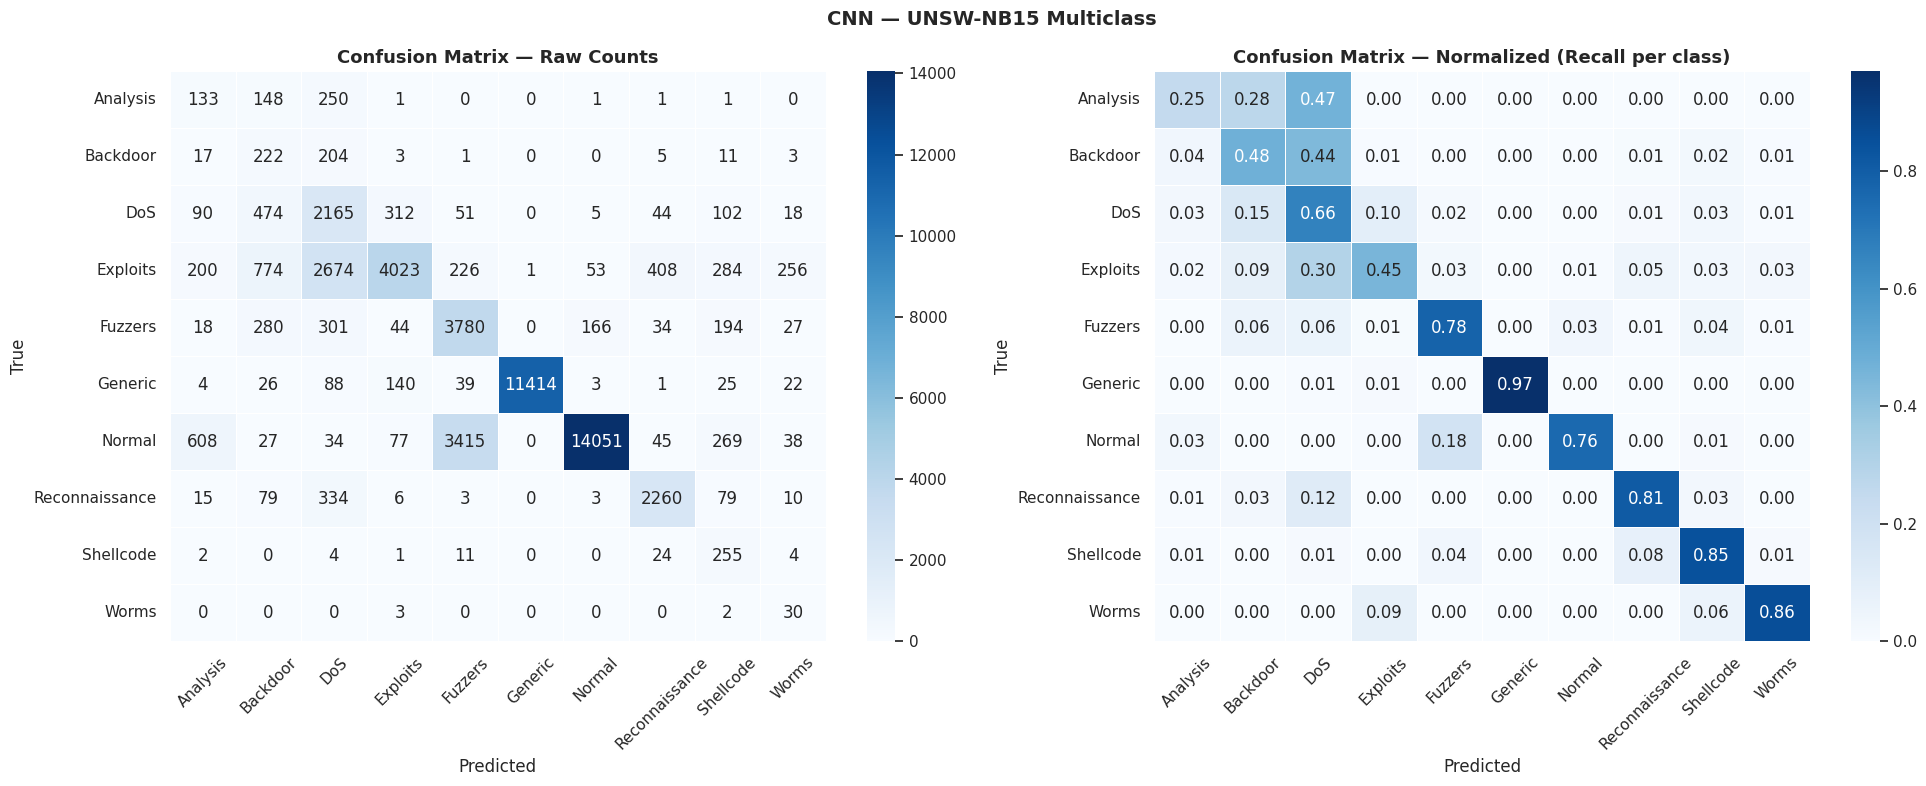

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

cm_norm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-8)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Normalized (Recall per class)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('CNN — UNSW-NB15 Multiclass', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_cnn_multi.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. ROC Curves (Per Class : One-vs-Rest)

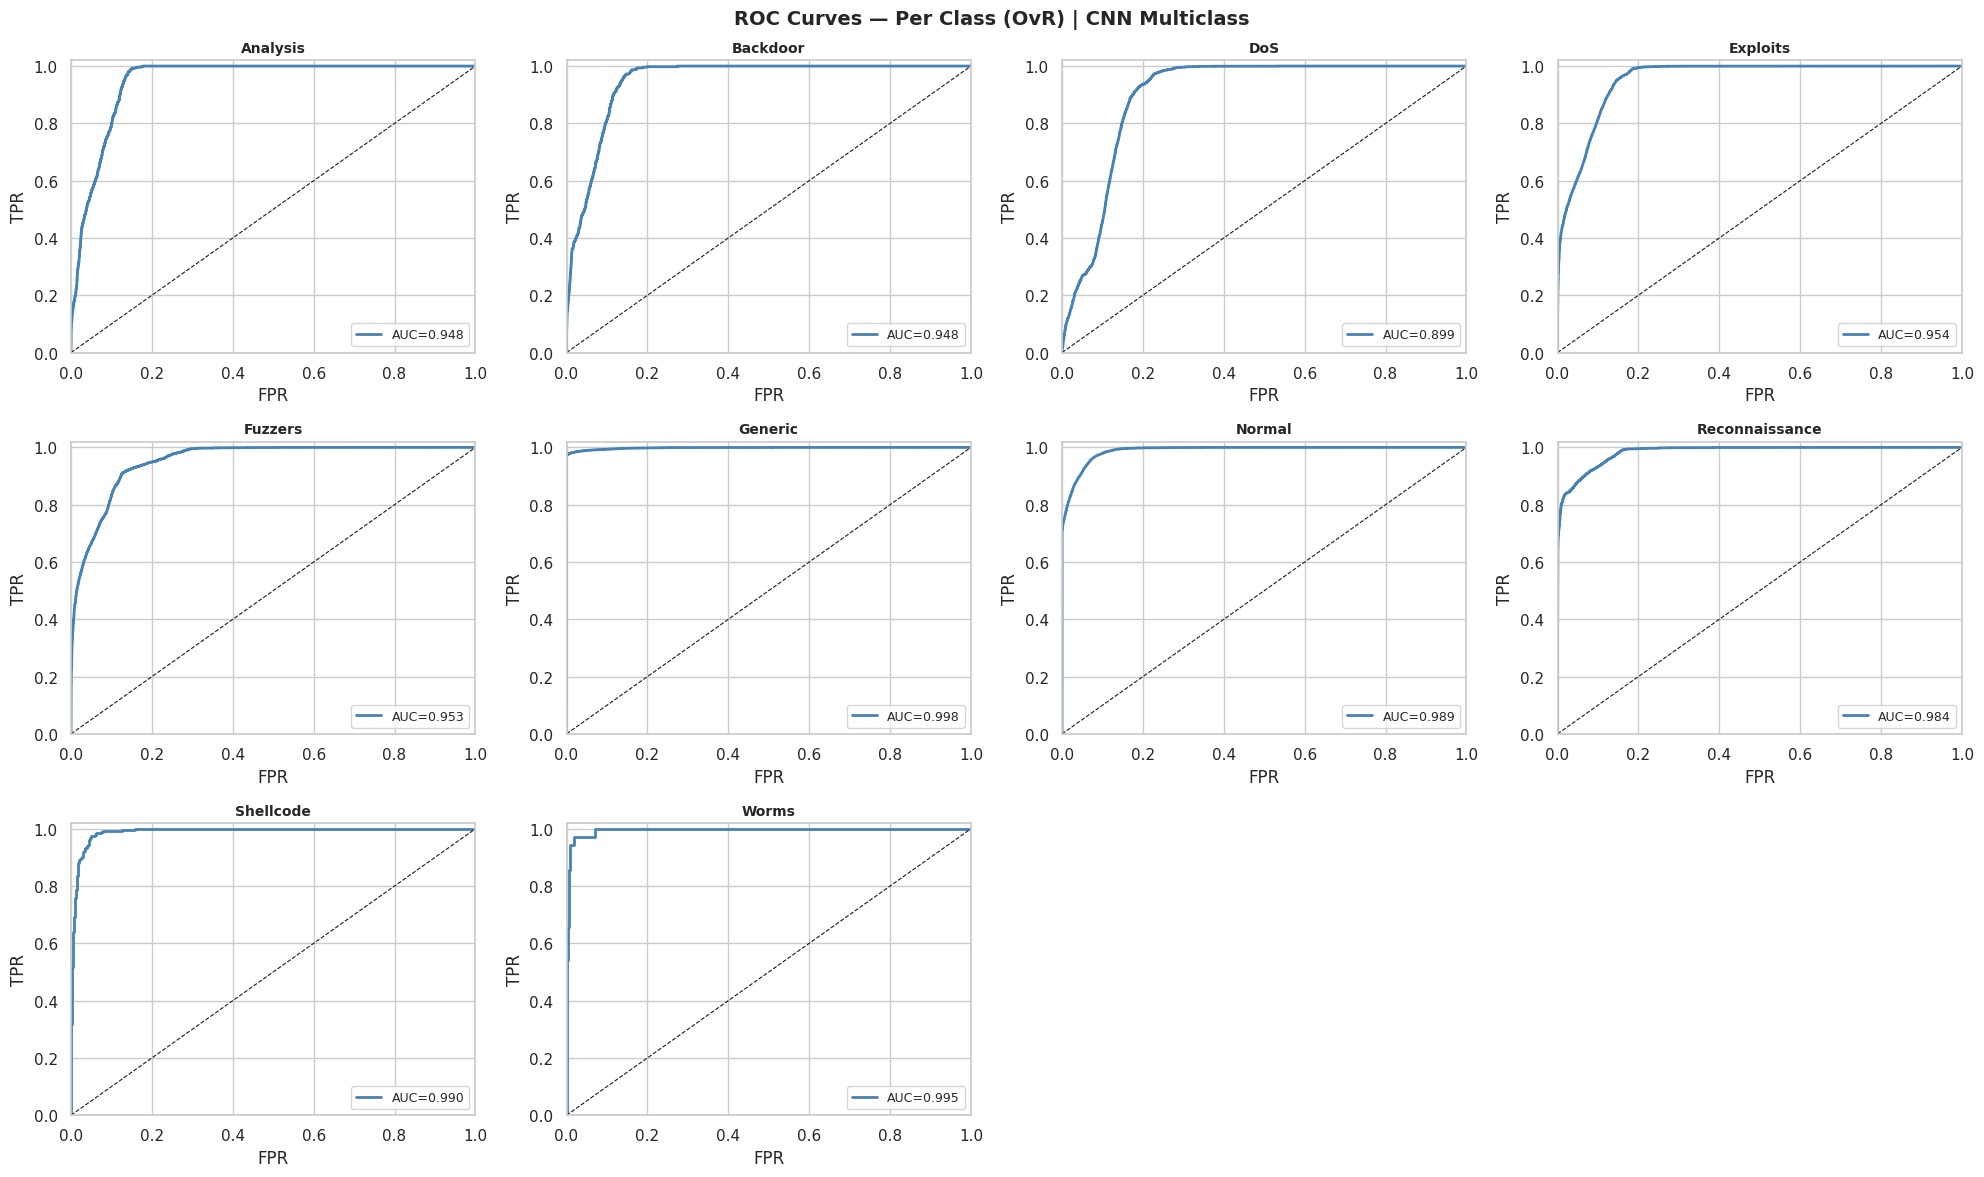

Per-class AUC:
  Analysis             AUC = 0.9476
  Backdoor             AUC = 0.9477
  DoS                  AUC = 0.8989
  Exploits             AUC = 0.9536
  Fuzzers              AUC = 0.9526
  Generic              AUC = 0.9982
  Normal               AUC = 0.9888
  Reconnaissance       AUC = 0.9836
  Shellcode            AUC = 0.9904
  Worms                AUC = 0.9949


In [18]:
y_bin  = label_binarize(y_true, classes=list(range(N_CLASSES)))
n_cols = 4
n_rows = int(np.ceil(N_CLASSES / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

per_class_auc = []
for c in range(N_CLASSES):
    if y_bin[:, c].sum() == 0:
        per_class_auc.append(float('nan'))
        axes[c].set_visible(False)
        continue
    fpr_c, tpr_c, _ = roc_curve(y_bin[:, c], y_probs[:, c])
    auc_c = auc(fpr_c, tpr_c)
    per_class_auc.append(auc_c)
    axes[c].plot(fpr_c, tpr_c, lw=2, color='steelblue', label=f'AUC={auc_c:.3f}')
    axes[c].plot([0,1],[0,1],'k--', lw=0.8)
    axes[c].set_title(CLASS_NAMES[c], fontsize=10, fontweight='bold')
    axes[c].set_xlabel('FPR'); axes[c].set_ylabel('TPR')
    axes[c].legend(fontsize=9)
    axes[c].set_xlim([0,1]); axes[c].set_ylim([0,1.02])

for ax in axes[N_CLASSES:]:
    ax.set_visible(False)

plt.suptitle('ROC Curves — Per Class (OvR) | CNN Multiclass',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves_cnn_multi.png', dpi=150, bbox_inches='tight')
plt.show()

print('Per-class AUC:')
for c, a in enumerate(per_class_auc):
    print(f'  {CLASS_NAMES[c]:<20} AUC = {a:.4f}')

## 17. Precision-Recall Curves (Per Class)

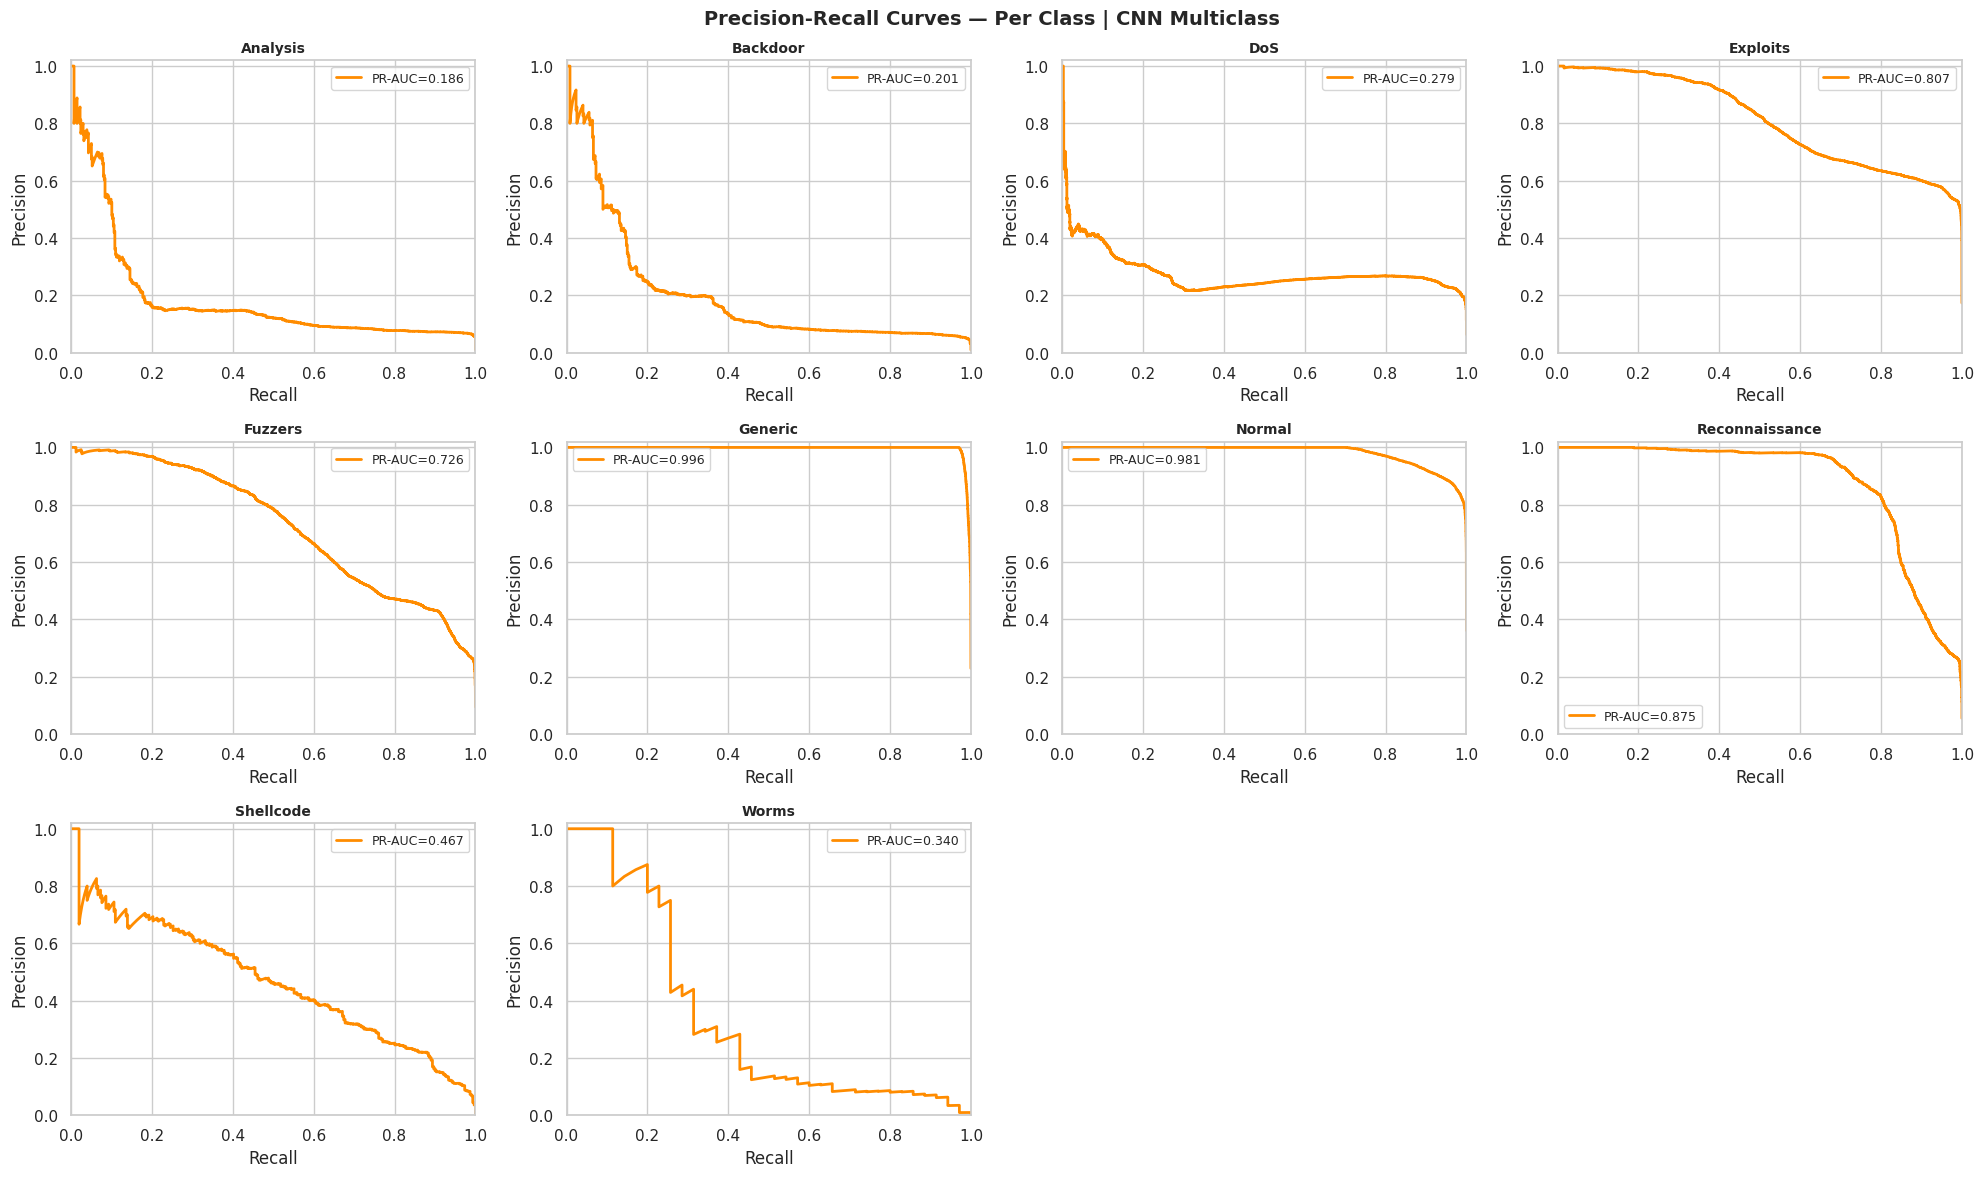

In [19]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for c in range(N_CLASSES):
    if y_bin[:, c].sum() == 0:
        axes[c].set_visible(False)
        continue
    prec_c, rec_c, _ = precision_recall_curve(y_bin[:, c], y_probs[:, c])
    pr_auc = auc(rec_c, prec_c)
    axes[c].plot(rec_c, prec_c, lw=2, color='darkorange', label=f'PR-AUC={pr_auc:.3f}')
    axes[c].set_title(CLASS_NAMES[c], fontsize=10, fontweight='bold')
    axes[c].set_xlabel('Recall'); axes[c].set_ylabel('Precision')
    axes[c].legend(fontsize=9)
    axes[c].set_xlim([0,1]); axes[c].set_ylim([0,1.02])

for ax in axes[N_CLASSES:]:
    ax.set_visible(False)

plt.suptitle('Precision-Recall Curves — Per Class | CNN Multiclass',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pr_curves_cnn_multi.png', dpi=150, bbox_inches='tight')
plt.show()

## 18. Per-Class Metric Bar Charts

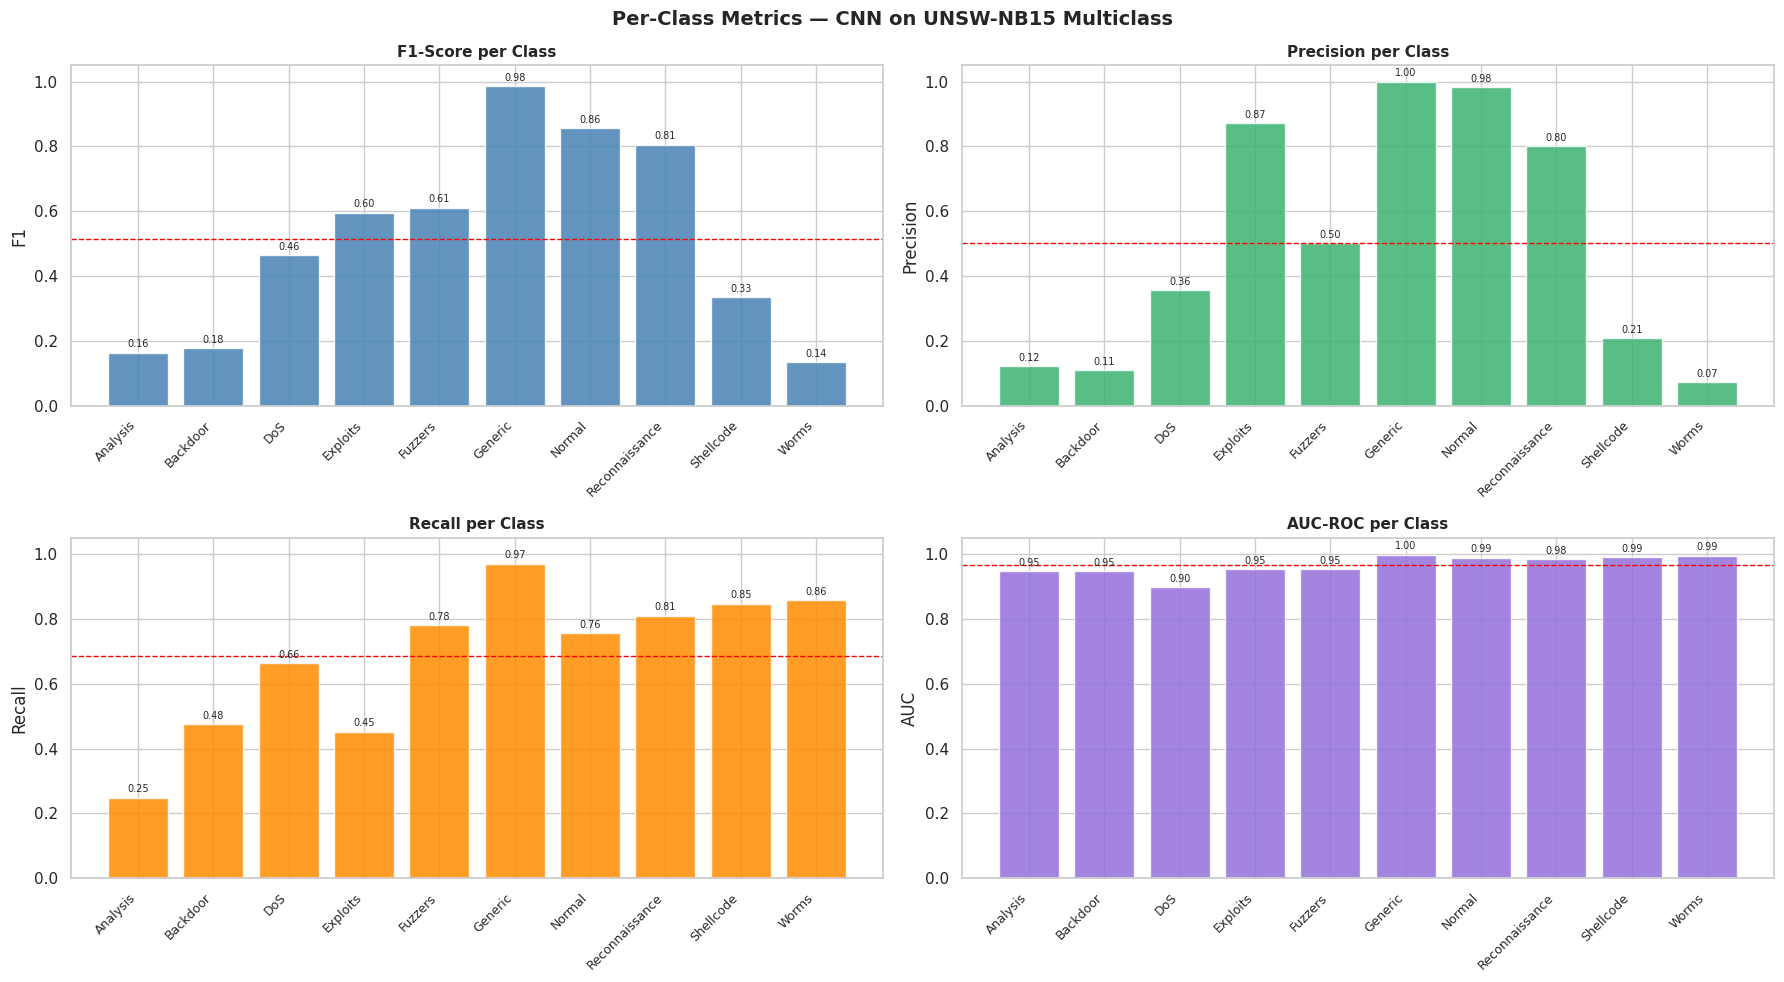

In [20]:
report = classification_report(
    y_true, y_pred, target_names=CLASS_NAMES,
    output_dict=True, zero_division=0
)
f1_per   = [report[c]['f1-score']  for c in CLASS_NAMES]
prec_per = [report[c]['precision'] for c in CLASS_NAMES]
rec_per  = [report[c]['recall']    for c in CLASS_NAMES]

def bar_chart(ax, vals, title, ylabel, color):
    bars = ax.bar(range(N_CLASSES), vals, color=color, edgecolor='white', alpha=0.85)
    ax.set_xticks(range(N_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel); ax.set_ylim(0, 1.05)
    ax.axhline(np.nanmean(vals), color='red', linestyle='--', lw=1)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
bar_chart(axes[0,0], f1_per,         'F1-Score per Class',  'F1',        'steelblue')
bar_chart(axes[0,1], prec_per,       'Precision per Class', 'Precision', 'mediumseagreen')
bar_chart(axes[1,0], rec_per,        'Recall per Class',    'Recall',    'darkorange')
bar_chart(axes[1,1], per_class_auc,  'AUC-ROC per Class',   'AUC',       'mediumpurple')

plt.suptitle('Per-Class Metrics — CNN on UNSW-NB15 Multiclass',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('per_class_metrics_cnn_multi.png', dpi=150, bbox_inches='tight')
plt.show()

## 19. Training Curves (CV Folds)

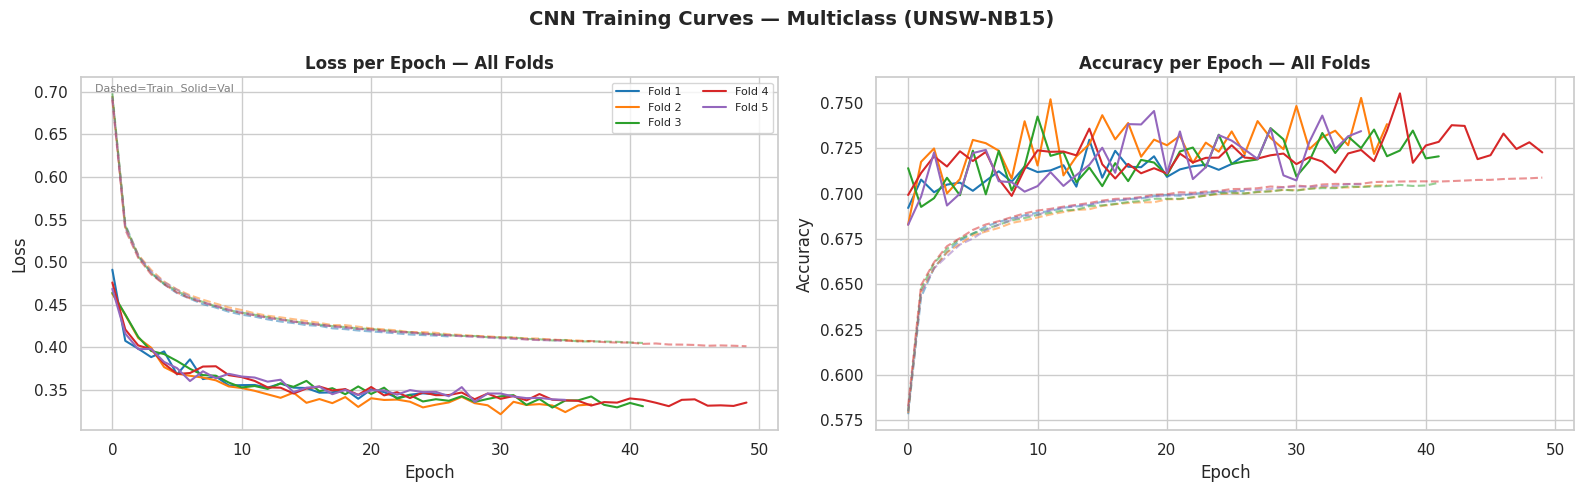

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = plt.cm.tab10.colors

for i, hist in enumerate(cv_histories):
    c = colors[i]
    axes[0].plot(hist['train_loss'], color=c, alpha=0.5, linestyle='--')
    axes[0].plot(hist['val_loss'],   color=c, alpha=1.0, label=f'Fold {i+1}')
    axes[1].plot(hist['train_acc'],  color=c, alpha=0.5, linestyle='--')
    axes[1].plot(hist['val_acc'],    color=c, alpha=1.0)

axes[0].set_title('Loss per Epoch — All Folds', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8, ncol=2)
axes[0].text(0.02, 0.98, 'Dashed=Train  Solid=Val',
             transform=axes[0].transAxes, fontsize=8, va='top', color='gray')
axes[1].set_title('Accuracy per Epoch — All Folds', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')

plt.suptitle('CNN Training Curves — Multiclass (UNSW-NB15)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 20. Individual Metric Plots (9 plots)

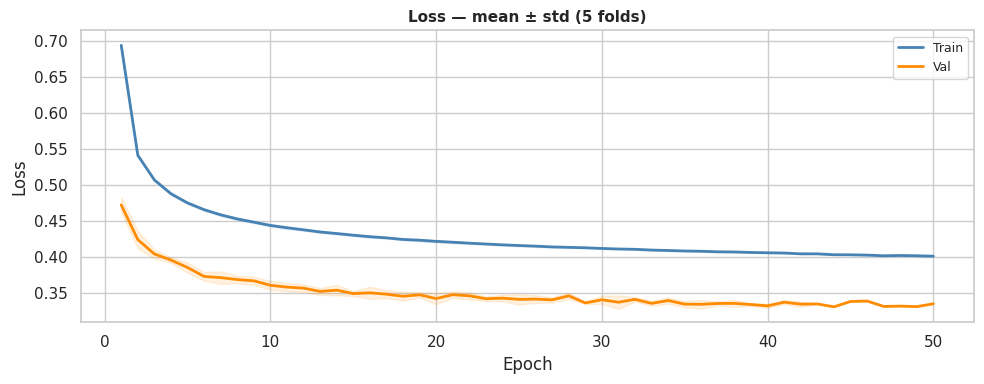

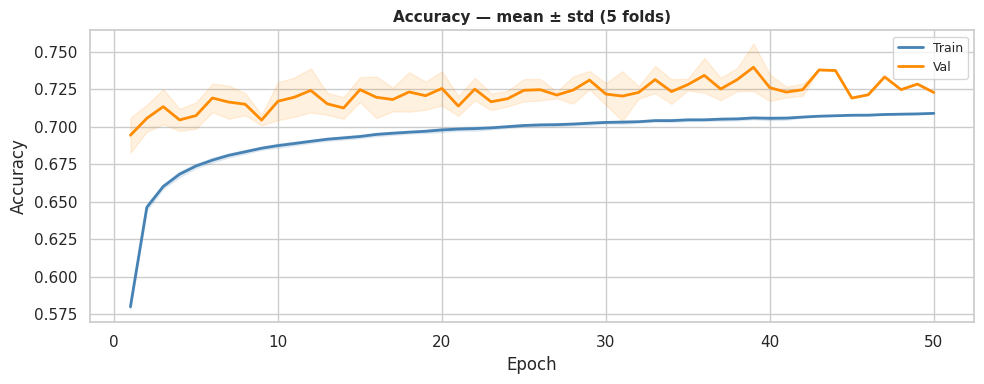

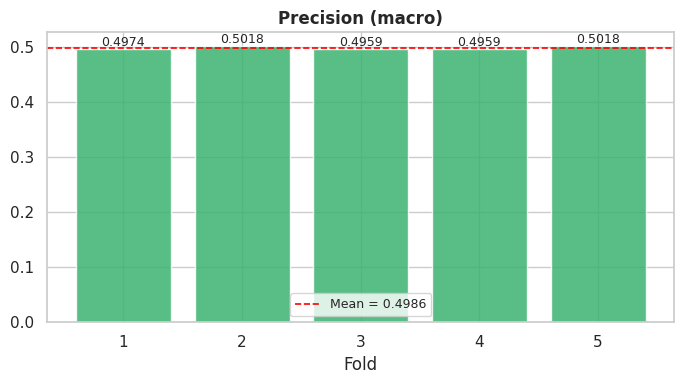

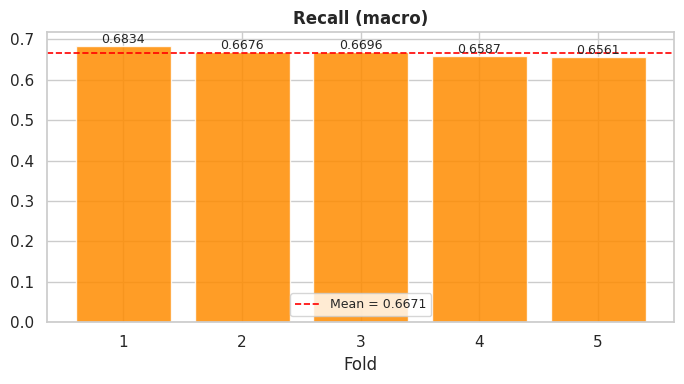

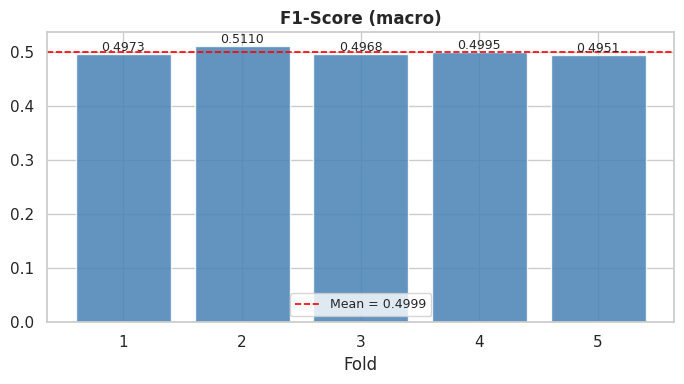

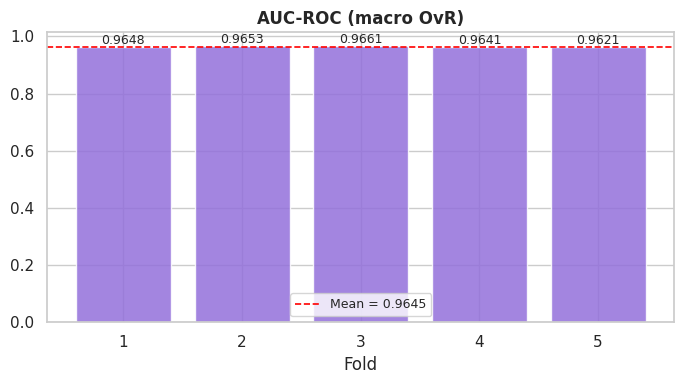

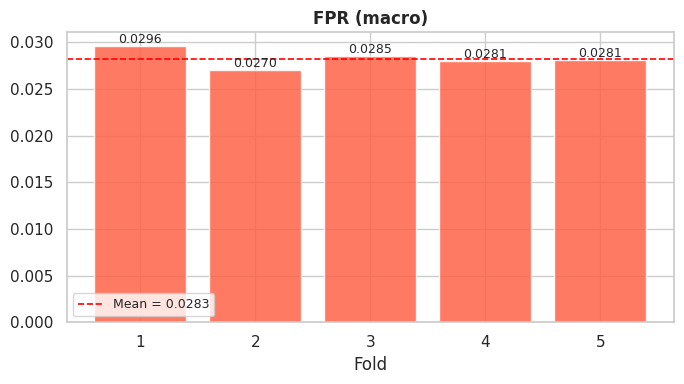

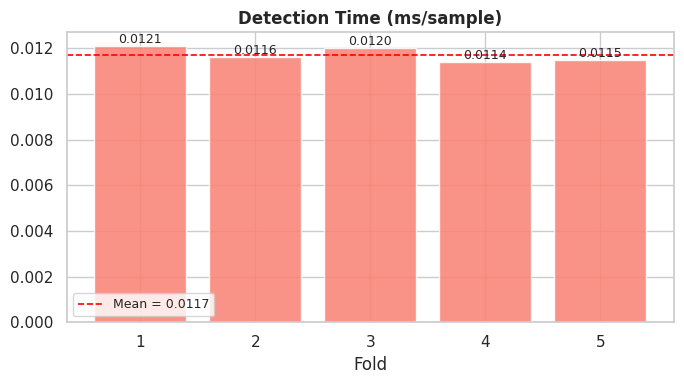

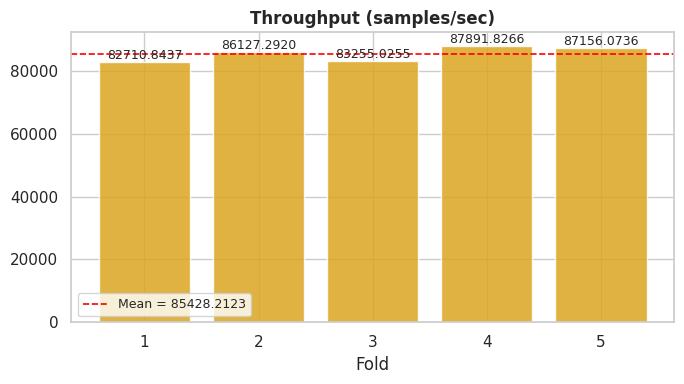

 All 9 individual metric plots saved.


In [22]:
#  Mean ± std training curves
max_ep = max(len(h['train_loss']) for h in cv_histories)

def pad(key):
    arrs = []
    for h in cv_histories:
        a = np.array(h[key])
        if len(a) < max_ep:
            a = np.concatenate([a, np.full(max_ep - len(a), np.nan)])
        arrs.append(a)
    return np.array(arrs)

tr_loss_m = pad('train_loss'); vl_loss_m = pad('val_loss')
tr_acc_m  = pad('train_acc');  vl_acc_m  = pad('val_acc')
ep_x = np.arange(1, max_ep + 1)

def curve_plot(ax, tr, vl, title, ylabel):
    m_tr = np.nanmean(tr, 0); s_tr = np.nanstd(tr, 0)
    m_vl = np.nanmean(vl, 0); s_vl = np.nanstd(vl, 0)
    ax.plot(ep_x, m_tr, 'steelblue',  lw=2, label='Train')
    ax.fill_between(ep_x, m_tr-s_tr, m_tr+s_tr, alpha=0.12, color='steelblue')
    ax.plot(ep_x, m_vl, 'darkorange', lw=2, label='Val')
    ax.fill_between(ep_x, m_vl-s_vl, m_vl+s_vl, alpha=0.12, color='darkorange')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.legend(fontsize=9)

# 1. Loss
fig, ax = plt.subplots(figsize=(10,4))
curve_plot(ax, tr_loss_m, vl_loss_m, 'Loss — mean ± std (5 folds)', 'Loss')
plt.tight_layout(); plt.savefig('plot_loss.png', dpi=150, bbox_inches='tight'); plt.show()

# 2. Accuracy
fig, ax = plt.subplots(figsize=(10,4))
curve_plot(ax, tr_acc_m, vl_acc_m, 'Accuracy — mean ± std (5 folds)', 'Accuracy')
plt.tight_layout(); plt.savefig('plot_accuracy.png', dpi=150, bbox_inches='tight'); plt.show()

# 3–9. Per-fold scalar metrics
scalar_plots = [
    ('precision',   'Precision (macro)',          'mediumseagreen'),
    ('recall',      'Recall (macro)',             'darkorange'),
    ('f1',          'F1-Score (macro)',           'steelblue'),
    ('roc_auc',     'AUC-ROC (macro OvR)',        'mediumpurple'),
    ('fpr',         'FPR (macro)',                'tomato'),
    ('det_time_ms', 'Detection Time (ms/sample)', 'salmon'),
    ('throughput',  'Throughput (samples/sec)',   'goldenrod'),
]

for col, title, color in scalar_plots:
    vals = cv_df[col].values
    fig, ax = plt.subplots(figsize=(7,4))
    bars = ax.bar(range(1, N_FOLDS+1), vals, color=color, edgecolor='white', alpha=0.85)
    ax.axhline(vals.mean(), color='red', linestyle='--', lw=1.2,
               label=f'Mean = {vals.mean():.4f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Fold'); ax.set_xticks(range(1, N_FOLDS+1))
    ax.legend(fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'plot_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()

print(' All 9 individual metric plots saved.')

## 21. Per-Fold Summary Bar Chart

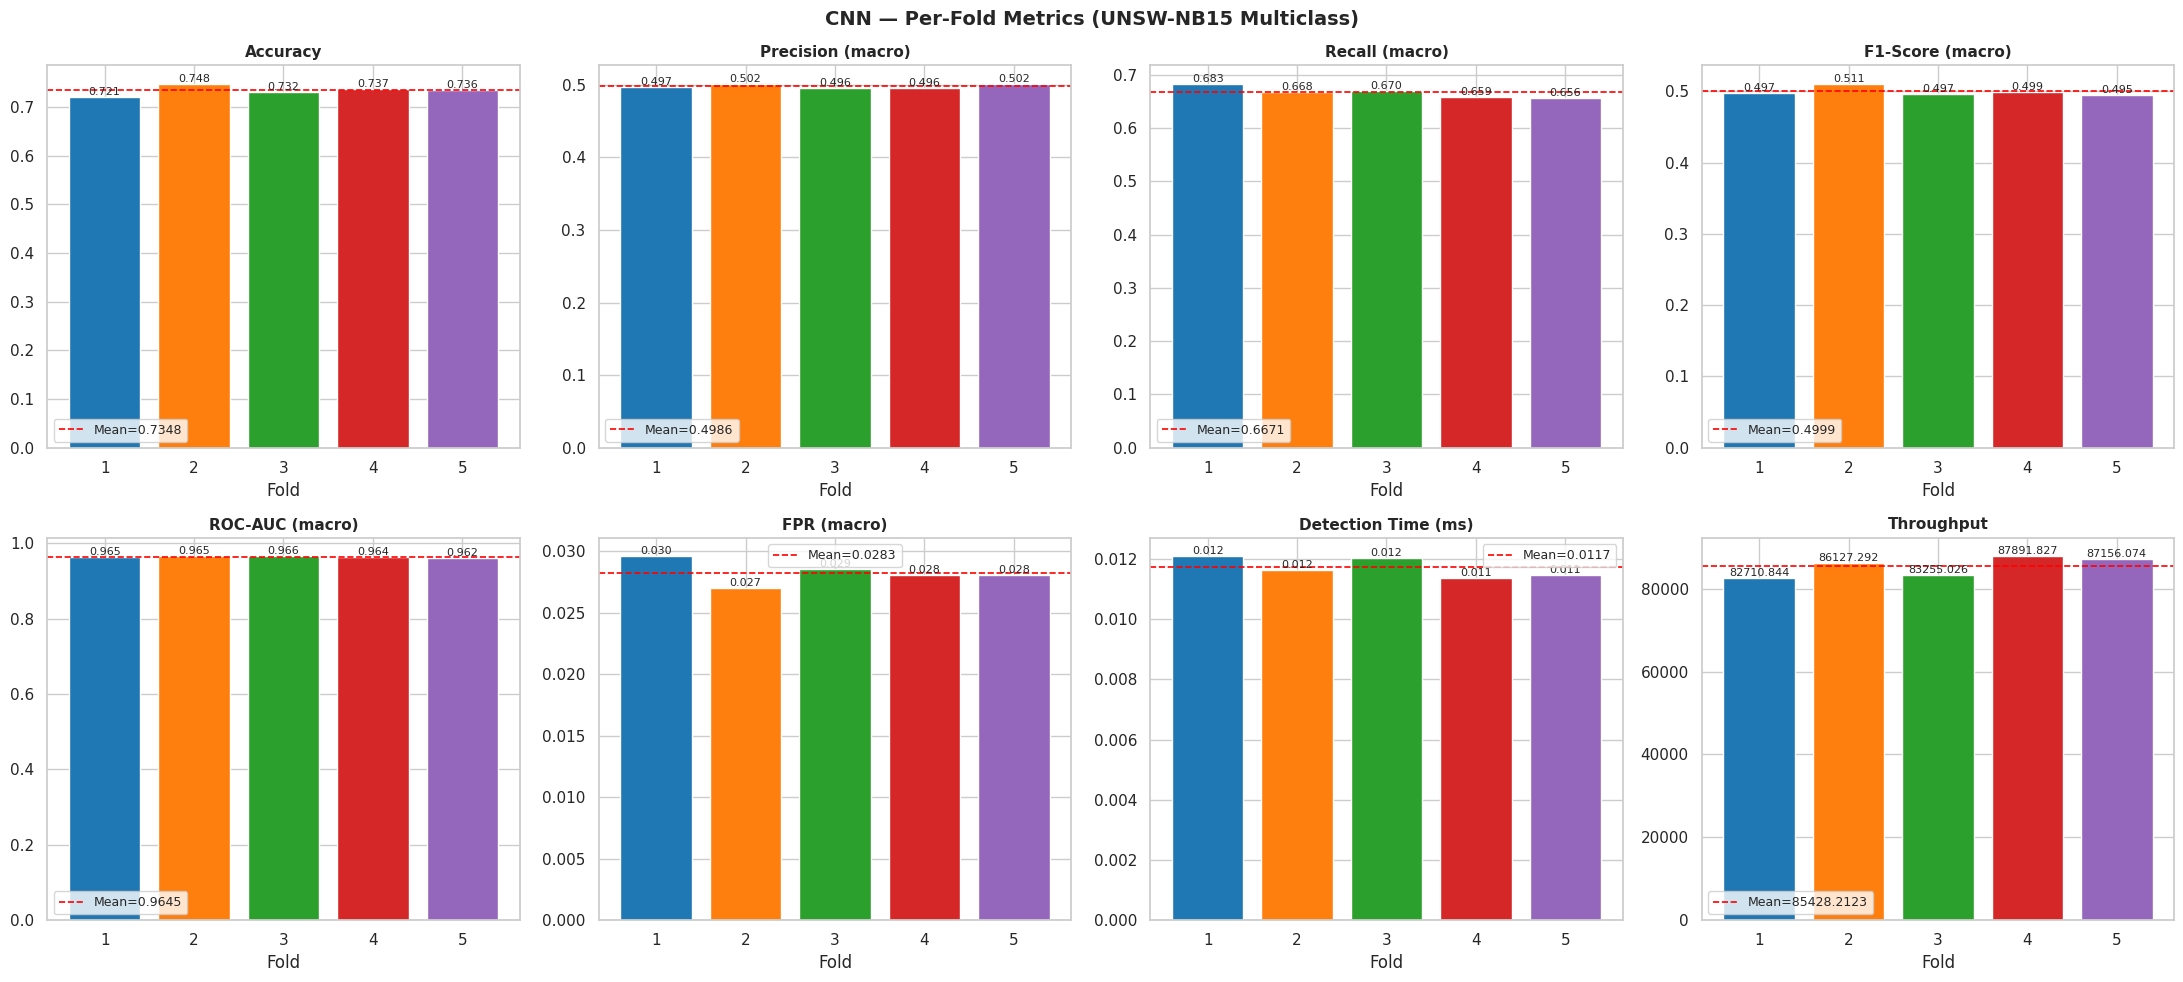

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes  = axes.flatten()
folds = cv_df.index.tolist()

all_metrics = [
    ('acc',         'Accuracy'),
    ('precision',   'Precision (macro)'),
    ('recall',      'Recall (macro)'),
    ('f1',          'F1-Score (macro)'),
    ('roc_auc',     'ROC-AUC (macro)'),
    ('fpr',         'FPR (macro)'),
    ('det_time_ms', 'Detection Time (ms)'),
    ('throughput',  'Throughput'),
]

for ax, (col, title) in zip(axes, all_metrics):
    vals = cv_df[col].values
    bars = ax.bar(folds, vals, color=plt.cm.tab10.colors[:N_FOLDS], edgecolor='white')
    ax.axhline(vals.mean(), color='red', linestyle='--', lw=1.2,
               label=f'Mean={vals.mean():.4f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Fold'); ax.set_xticks(folds)
    ax.legend(fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('CNN — Per-Fold Metrics (UNSW-NB15 Multiclass)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('per_fold_metrics_cnn_multi.png', dpi=150, bbox_inches='tight')
plt.show()

## 22. Save Best Model

In [24]:
save_path = 'cnn_unsw_nb15_multiclass_best.pt'
torch.save({
    'model_state_dict': best_model.state_dict(),
    'n_features'      : N_FEATURES,
    'n_classes'       : N_CLASSES,
    'class_names'     : CLASS_NAMES,
    'cnn_blocks'      : CNN_BLOCKS,
    'cnn_dropout'     : CNN_DROPOUT,
    'pool_size'       : POOL_SIZE,
    'fc_layers'       : FC_LAYERS,
    'fc_dropout'      : FC_DROPOUT,
    'best_fold'       : best_fold_idx + 1,
    'label_encoder'   : le,
    'cv_results'      : cv_df.to_dict(),
    'test_metrics'    : {
        'acc': acc, 'precision': prec, 'recall': rec, 'f1': f1,
        'fpr': fpr_macro, 'roc_auc': roc_auc,
        'det_time_ms': det_time_ms, 'throughput': throughput
    }
}, save_path)
print(f' Model saved → {save_path}')
print(f'  Architecture : CNN1D  blocks={CNN_BLOCKS}')
print(f'  Classes      : {N_CLASSES}  {CLASS_NAMES}')
print(f'  Best fold    : {best_fold_idx + 1}')


 Model saved → cnn_unsw_nb15_multiclass_best.pt
  Architecture : CNN1D  blocks=[(64, 3), (128, 3), (256, 3)]
  Classes      : 10  ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']
  Best fold    : 2
